In [3]:
# 1. IMPORTS & CONFIGURATION 
#   Importacion de librerias

import pandas as pd
import numpy as np

In [6]:
# 2. CAREGA DE DADES 
# Llegir archius CSV --> pd.read_csv() 
print("--- 2. Carega de dades ---")
df = pd.read_csv('Coffee Shop Sales.csv', sep=';', encoding='latin-1')

    #sep=';' perque el arichiu utilitza punt i coma com a delimitador
    #encoding='latin-1' per evitar problemes amb caràcters especials

# Parsear dates --> pd.to_datetime()
if 'transaction_date' in df.columns:
    df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='%d/%m/%Y')

    #format='%d/%m/%Y' perque les dates estiguin en format dia/mes/any

# Mostrar les primeres linies
print("--- Primeres linies del dataset ---")
print(df[0:5])

# Resum informatiu --> df.info()
print("\n--- Resum informatiu del dataset ---")
df.info()

# Resum estadístic --> df.describe()
print("\n--- Resum estadístic del dataset ---")
print(df.describe())

--- 2. Carega de dades ---
--- Primeres linies del dataset ---
   ï»¿transaction_id transaction_date transaction_time  transaction_qty  \
0                  1       2023-01-01          7:06:11                2   
1                  2       2023-01-01          7:08:56                2   
2                  3       2023-01-01          7:14:04                2   
3                  4       2023-01-01          7:20:24                1   
4                  5       2023-01-01          7:22:41                2   

   store_id   store_location  product_id unit_price    product_category  \
0         5  Lower Manhattan          32          3              Coffee   
1         5  Lower Manhattan          57        3,1                 Tea   
2         5  Lower Manhattan          59        4,5  Drinking Chocolate   
3         5  Lower Manhattan          22          2              Coffee   
4         5  Lower Manhattan          57        3,1                 Tea   

            product_type           

In [8]:
# --- 3. NETEJA I PREPARACIÓ DE DADES ---
print("--- 3. Neteja i preparació de dades ---")

# 1. Convertir 'transaction_time' al tipus apropiat
if 'transaction_time' in df.columns:
    df['transaction_time'] = pd.to_datetime(df['transaction_time'], errors='coerce')

print(df.info())

# 2. Assegurar que les columnes numèriques són numèriques
for col in ['transaction_qty', 'unit_price']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Crear una nova columna 'total_price'
if 'transaction_qty' in df.columns and 'unit_price' in df.columns:
    df['total_price'] = df['transaction_qty'] * df['unit_price']

cols_to_show = [c for c in ['transaction_qty', 'unit_price', 'total_price'] if c in df.columns]
print("\nPrimeres files (usant slicing 0:5):\n")
print(df[cols_to_show][0:5])


# 4. Detecció i tractament de nuls
print("\n--- 4. Detecció de Valors Nuls ---")
print("Total de Nuls per columna:\n", df.isna().sum())

#Omplir nuls en 'transaction_qty' amb 0
if 'transaction_qty' in df.columns:
    df['transaction_qty'] = df['transaction_qty'].fillna(0)

#Eliminar files amb 'transaction_time' no convertida (NaT)
if 'transaction_time' in df.columns:
    before = len(df)
    df = df.dropna(subset=['transaction_time'])
    after = len(df)
    print(f"Files eliminades per transaction_time nuls: {before-after}")

print("\nNuls restants després del tractament:\n", df.isna().sum())

# 5. Detecció de valors atípics (Outliers) — utilitzem 99è percentil
print("\n--- 5. Detecció i Tractament d'Outliers (p. ex. 99 Percentil) ---")
if 'total_price' in df.columns:
    q_99 = df['total_price'].quantile(0.99)
    print(f"El 99è Percentil per a 'total_price' és: {q_99:,.2f}")

    df_cleaned = df[df['total_price'] <= q_99]
    
    print(f"\nFiles originals: {len(df)}. Files després d'eliminar outliers: {len(df_cleaned)}")
else:
    print("No es pot calcular outliers: columna 'total_price' no existeix.")
    df_cleaned = df

--- 3. Neteja i preparació de dades ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ï»¿transaction_id  149116 non-null  int64         
 1   transaction_date   149116 non-null  datetime64[ns]
 2   transaction_time   149116 non-null  datetime64[ns]
 3   transaction_qty    149116 non-null  int64         
 4   store_id           149116 non-null  int64         
 5   store_location     149116 non-null  object        
 6   product_id         149116 non-null  int64         
 7   unit_price         44038 non-null   float64       
 8   product_category   149116 non-null  object        
 9   product_type       149116 non-null  object        
 10  product_detail     149116 non-null  object        
 11  total_price        44038 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(4), object(4)
memory

In [ ]:
# 4. ANALISIS EXPLORATORIO 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Cargar el CSV (separado por ';')
df = pd.read_csv('Coffee Shop Sales.csv', sep=';')

# Convertir unit_price de string con coma decimal a float
# Ej: "3,1" -> 3.1
df['unit_price'] = (
    df['unit_price']
    .astype(str)             # aseguramos tipo string
    .str.replace(',', '.')   # cambiamos coma por punto
)

df['unit_price'] = pd.to_numeric(df['unit_price'], errors='coerce')

# Asegurar que transaction_qty es numérico
df['transaction_qty'] = pd.to_numeric(df['transaction_qty'], errors='coerce')

# Crear columna total_price = unit_price * transaction_qty
df['total_price'] = df['unit_price'] * df['transaction_qty']

# Extraer la hora de transaction_time (formato HH:MM:SS)
df['transaction_hour'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour

# 4.1  Estadísticas globales
print("\n=== 4.1 ESTADÍSTICAS GLOBALES ===\n")

numeric_cols = ['unit_price', 'total_price', 'transaction_qty']

stats = df[numeric_cols].agg(['mean', 'median', 'std', 'min', 'max']).T
stats = stats.rename(columns={
    'mean': 'media',
    'median': 'mediana',
    'std': 'desviacion_estandar',
    'min': 'minimo',
    'max': 'maximo'
})

print("Estadísticas globales de unit_price, total_price y transaction_qty:\n")
print(stats.round(2))

# Número de transacciones
n_transactions = len(df)
# Número de tiendas distintas
n_stores = df['store_id'].nunique()
# Número de ubicaciones distintas
n_locations = df['store_location'].nunique()

print("\nNúmero total de transacciones:", n_transactions)
print("Número de tiendas distintas (store_id):", n_stores)
print("Número de ubicaciones distintas (store_location):", n_locations)

# 4.2 DISTRIBUCIÓN POR CATEGORÍA DE PRODUCTO

print("\n=== 4.2 DISTRIBUCIÓN POR CATEGORÍA DE PRODUCTO ===\n")

cat_group = df.groupby('product_category').agg(
    n_transacciones=('transaction_id', 'count'),
    importe_total=('total_price', 'sum'),
    importe_medio=('total_price', 'mean')
).sort_values(by='importe_total', ascending=False)

print("Métricas por categoría de producto (ordenado por importe_total desc):\n")
print(cat_group.round(2))

# Reflexión simple programática: categoría que más ingresa
top_cat = cat_group['importe_total'].idxmax()
top_cat_value = cat_group['importe_total'].max()

print(f"\nLa categoría que genera más ingresos es: '{top_cat}' "
      f"con un importe total de {top_cat_value:.2f}.")

# 4.3 AGRUPACIONES POR TIENDA / UBICACIÓN

print("\n=== 4.3 AGRUPACIONES POR TIENDA / UBICACIÓN ===\n")

# Por ubicación (store_location)
loc_group = df.groupby('store_location').agg(
    n_transacciones=('transaction_id', 'count'),
    importe_total=('total_price', 'sum'),
    importe_medio=('total_price', 'mean')
).sort_values(by='importe_medio', ascending=False)

print("Agrupación por ubicación (store_location):\n")
print(loc_group.round(2))

# Por store_id
store_group = df.groupby('store_id').agg(
    n_transacciones=('transaction_id', 'count'),
    importe_total=('total_price', 'sum'),
    importe_medio=('total_price', 'mean')
).sort_values(by='importe_medio', ascending=False)

print("\nAgrupación por tienda (store_id):\n")
print(store_group.round(2))

# Detectar cuál tiene mayor importe medio y cuál más transacciones
loc_max_ticket = loc_group['importe_medio'].idxmax()
loc_max_trans = loc_group['n_transacciones'].idxmax()

print(f"\nUbicación con mayor importe medio por transacción: {loc_max_ticket}")
print(f"Ubicación con mayor número de transacciones: {loc_max_trans}")

# 4.4 ANÁLISIS TEMPORAL POR HORA

print("\n=== 4.4 ANÁLISIS TEMPORAL POR HORA ===\n")

hour_group = df.groupby('transaction_hour').agg(
    n_transacciones=('transaction_id', 'count'),
    importe_total=('total_price', 'sum')
).sort_index()

print("Transacciones por hora del día:\n")
print(hour_group)



=== 4.1 ESTADÍSTICAS GLOBALES ===

Estadísticas globales de unit_price, total_price y transaction_qty:

                 media  mediana  desviacion_estandar  minimo  maximo
unit_price        3.38     3.00                 2.66     0.8    45.0
total_price       4.69     3.75                 4.23     0.8   360.0
transaction_qty   1.44     1.00                 0.54     1.0     8.0

Número total de transacciones: 149116
Número de tiendas distintas (store_id): 3
Número de ubicaciones distintas (store_location): 3

=== 4.2 DISTRIBUCIÓN POR CATEGORÍA DE PRODUCTO ===

Métricas por categoría de producto (ordenado por importe_total desc):

                    n_transacciones  importe_total  importe_medio
product_category                                                 
Coffee                        58416      269952.45           4.62
Tea                           45449      196405.95           4.32
Bakery                        22796       82315.64           3.61
Drinking Chocolate            11


=== Percentiles de total_price ===
P25: 3.00 €
P50 (mediana): 3.75 €
P75: 6.00 €
P90: 7.50 €
P99: 18.00 €

=== Detección de valores atípicos usando IQR ===
Límite inferior: -1.50
Límite superior: 10.50
Número de posibles outliers: 3273


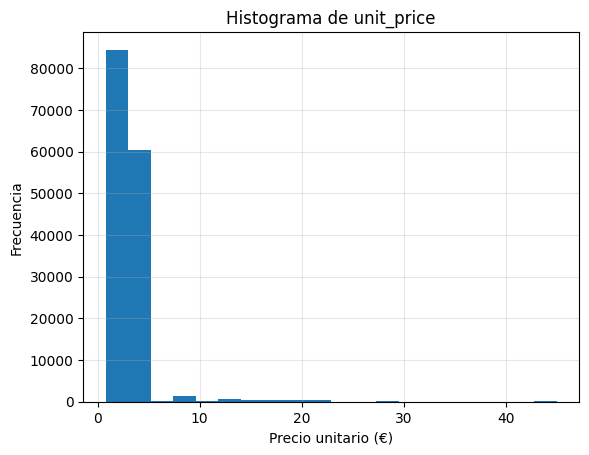

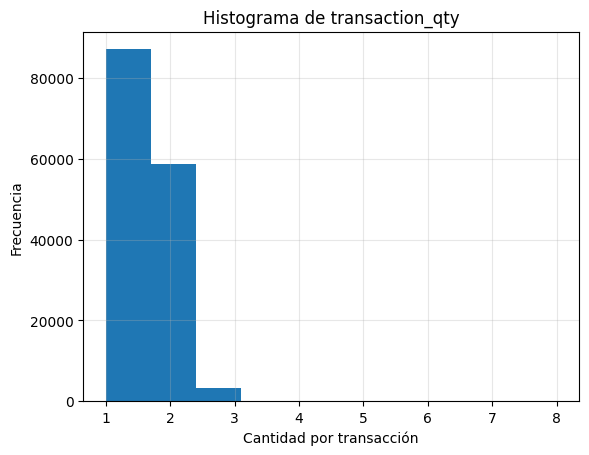

In [6]:

# 5. ANÁLISIS AUXILIAR CON NUMPY

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cargar dataset limpio
df = pd.read_csv("Coffee Shop Sales.csv", sep=";")
df['unit_price'] = df['unit_price'].astype(str).str.replace(',', '.')
df['unit_price'] = pd.to_numeric(df['unit_price'], errors='coerce')
df['transaction_qty'] = pd.to_numeric(df['transaction_qty'], errors='coerce')
df['total_price'] = df['unit_price'] * df['transaction_qty']

# 5.1 Cálculo de percentiles

p25 = np.percentile(df['total_price'], 25)
p50 = np.percentile(df['total_price'], 50)  # Mediana
p75 = np.percentile(df['total_price'], 75)
p90 = np.percentile(df['total_price'], 90)
p99 = np.percentile(df['total_price'], 99)

print("\n=== Percentiles de total_price ===")
print(f"P25: {p25:.2f} €")
print(f"P50 (mediana): {p50:.2f} €")
print(f"P75: {p75:.2f} €")
print(f"P90: {p90:.2f} €")
print(f"P99: {p99:.2f} €")

# 5.2 Detección de valores atípicos (IQR)

Q1 = p25
Q3 = p75
IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers = df[(df['total_price'] < limite_inf) | (df['total_price'] > limite_sup)]

print("\n=== Detección de valores atípicos usando IQR ===")
print(f"Límite inferior: {limite_inf:.2f}")
print(f"Límite superior: {limite_sup:.2f}")
print(f"Número de posibles outliers: {len(outliers)}")

# 5.3 Histogramas usando NumPy + Matplotlib


# Histograma de unit_price
plt.figure()
counts, bins = np.histogram(df['unit_price'].dropna(), bins=20)
plt.hist(df['unit_price'].dropna(), bins=20)
plt.title("Histograma de unit_price")
plt.xlabel("Precio unitario (€)")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)
plt.show()

# Histograma de transaction_qty
plt.figure()
counts2, bins2 = np.histogram(df['transaction_qty'].dropna(), bins=10)
plt.hist(df['transaction_qty'].dropna(), bins=10)
plt.title("Histograma de transaction_qty")
plt.xlabel("Cantidad por transacción")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)
plt.show()
